# Residual denoiser quick loop
Loads a residual checkpoint, optionally fine-tunes on a small subset, reports SNR gains, and plots all channels with `plot_traces`.


In [81]:
import h5py, torch, numpy as np, matplotlib.pyplot as plt
from pathlib import Path
from torch.utils.data import DataLoader, TensorDataset
from denoiser import CNNDenoiser1DResidual
from trace_IO import plot_traces

# Paths/config
h5_path = Path("/ceph/srv/dwong/training_samples_h5/wk28_pairs/NR_traces_energy_200_pair_batch_0038.h5")
ckpt_path = Path("/home/dwong/DELight_mtr/checkpoints/cnn_residual_final.pt")
chunk_size = 100  # events per chunk
num_chunks = 10   # number of chunks to use (total = chunk_size * num_chunks)
max_events = chunk_size * num_chunks
batch_size = 4
epochs = 6
lr = 1e-4
normalize = True  # per-event, per-channel std
channel_weight_mode = "none"  # options: "none", "inverse_std"
residual_l2_lambda = 1e-4  # penalty on predicted residual magnitude
run_finetune = True
plot_idx = 0  # which event to visualize with plot_traces

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device:", device)


device: cuda


In [82]:
# Load a subset of paired traces (keep raw copies for metrics/plots)
with h5py.File(h5_path, "r") as f:
    total_events = f["traces"].shape[0]
    use_events = min(max_events, total_events)
    noisy_raw = torch.from_numpy(f["traces"][:use_events].astype(np.float32))
    clean_raw = torch.from_numpy(f["traces_clean"][:use_events].astype(np.float32)) if "traces_clean" in f else noisy_raw.clone()

print(f"Loaded noisy {tuple(noisy_raw.shape)}, clean {tuple(clean_raw.shape)} from {h5_path} (using {use_events}/{total_events} events)")

noisy = noisy_raw.clone()
clean = clean_raw.clone()
scale = None
if normalize:
    # per-event, per-channel std normalization; avoids division by zero
    scale = noisy.std(dim=-1, keepdim=True).clamp(min=1e-6)
    noisy = noisy / scale
    clean = clean / scale

channel_weights = None
if channel_weight_mode == "inverse_std":
    # emphasize lower-variance channels (computed on raw noisy traces)
    channel_weights = 1.0 / noisy_raw.std(dim=(0, 2), keepdim=False).clamp(min=1e-6)
    channel_weights = channel_weights / channel_weights.mean()  # normalize around 1

dataset = TensorDataset(noisy, clean)
loader = DataLoader(dataset, batch_size=batch_size, shuffle=True)


Loaded noisy (100, 56, 65536), clean (100, 56, 65536) from /ceph/srv/dwong/training_samples_h5/wk28_pairs/NR_traces_energy_200_pair_batch_0038.h5 (using 100/100 events)


In [83]:
# Build model and load checkpoint if present
in_channels = noisy.shape[1]
model = CNNDenoiser1DResidual(in_channels=in_channels).to(device)
if ckpt_path.exists():
    state = torch.load(ckpt_path, map_location=device)
    model.load_state_dict(state["model"])
    print(f"Loaded pretrained weights from {ckpt_path}")
else:
    print(f"No checkpoint found at {ckpt_path}; training from scratch")


Loaded pretrained weights from /home/dwong/DELight_mtr/checkpoints/cnn_residual_final.pt


In [87]:
# Optional fine-tune on the small subset (with optional channel weights and residual penalty)
if run_finetune:
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    criterion = torch.nn.L1Loss()
    model.train()
    for epoch in range(epochs):
        running = 0.0
        for x_noisy, x_clean in loader:
            x_noisy = x_noisy.to(device)
            x_clean = x_clean.to(device)
            optimizer.zero_grad()
            pred = model(x_noisy)

            if channel_weights is None:
                loss_main = criterion(pred, x_clean)
            else:
                w = channel_weights.to(device).view(1, -1, 1)
                loss_main = (w * (pred - x_clean).abs()).mean()

            if residual_l2_lambda > 0:
                residual = pred - x_noisy
                loss_res = residual.pow(2).mean()
                loss = loss_main + residual_l2_lambda * loss_res
            else:
                loss = loss_main

            loss.backward()
            optimizer.step()
            running += loss.item() * x_noisy.size(0)
        print(f"Epoch {epoch + 1}/{epochs} | loss {running / len(dataset):.4e}")
    # Save scratch fine-tune checkpoint
    scratch_ckpt = ckpt_path.with_name("cnn_residual_finetune_latest.pt")
    torch.save({"model": model.state_dict()}, scratch_ckpt)
    print(f"Saved fine-tuned weights to {scratch_ckpt}")
else:
    print("Fine-tune skipped (run_finetune=False)")


Epoch 1/6 | loss 6.9883e-01
Epoch 2/6 | loss 6.0607e-01
Epoch 3/6 | loss 5.5242e-01
Epoch 4/6 | loss 5.2179e-01
Epoch 5/6 | loss 5.0259e-01
Epoch 6/6 | loss 4.9013e-01
Saved fine-tuned weights to /home/dwong/DELight_mtr/checkpoints/cnn_residual_finetune_latest.pt


In [88]:
# Inference and metrics
model.eval()
with torch.no_grad():
    preds = []
    for x_noisy, _ in loader:
        preds.append(model(x_noisy.to(device)).cpu())
pred = torch.cat(preds, dim=0)

# Denormalize predictions if needed
if scale is not None:
    pred_denorm = pred * scale
else:
    pred_denorm = pred

noisy_orig = noisy_raw
clean_orig = clean_raw

noise = clean_orig - pred_denorm
noise_power = torch.sum(noise ** 2, dim=(1, 2)).clamp(min=1e-12)
signal_power = torch.sum(clean_orig ** 2, dim=(1, 2)).clamp(min=1e-12)
snr = 10 * torch.log10(signal_power / noise_power)

noise_noisy = clean_orig - noisy_orig
noise_power_noisy = torch.sum(noise_noisy ** 2, dim=(1, 2)).clamp(min=1e-12)
snr_noisy = 10 * torch.log10(signal_power / noise_power_noisy)

snr_gain = snr - snr_noisy
print({
    "mse": torch.mean((pred_denorm - clean_orig) ** 2).item(),
    "mae": torch.mean(torch.abs(pred_denorm - clean_orig)).item(),
    "snr_db_mean": snr.mean().item(),
    "snr_gain_db_mean": snr_gain.mean().item(),
})


{'mse': 78.2861328125, 'mae': 4.499964237213135, 'snr_db_mean': -3.925367832183838, 'snr_gain_db_mean': -0.9246780872344971}


Plotting event 0


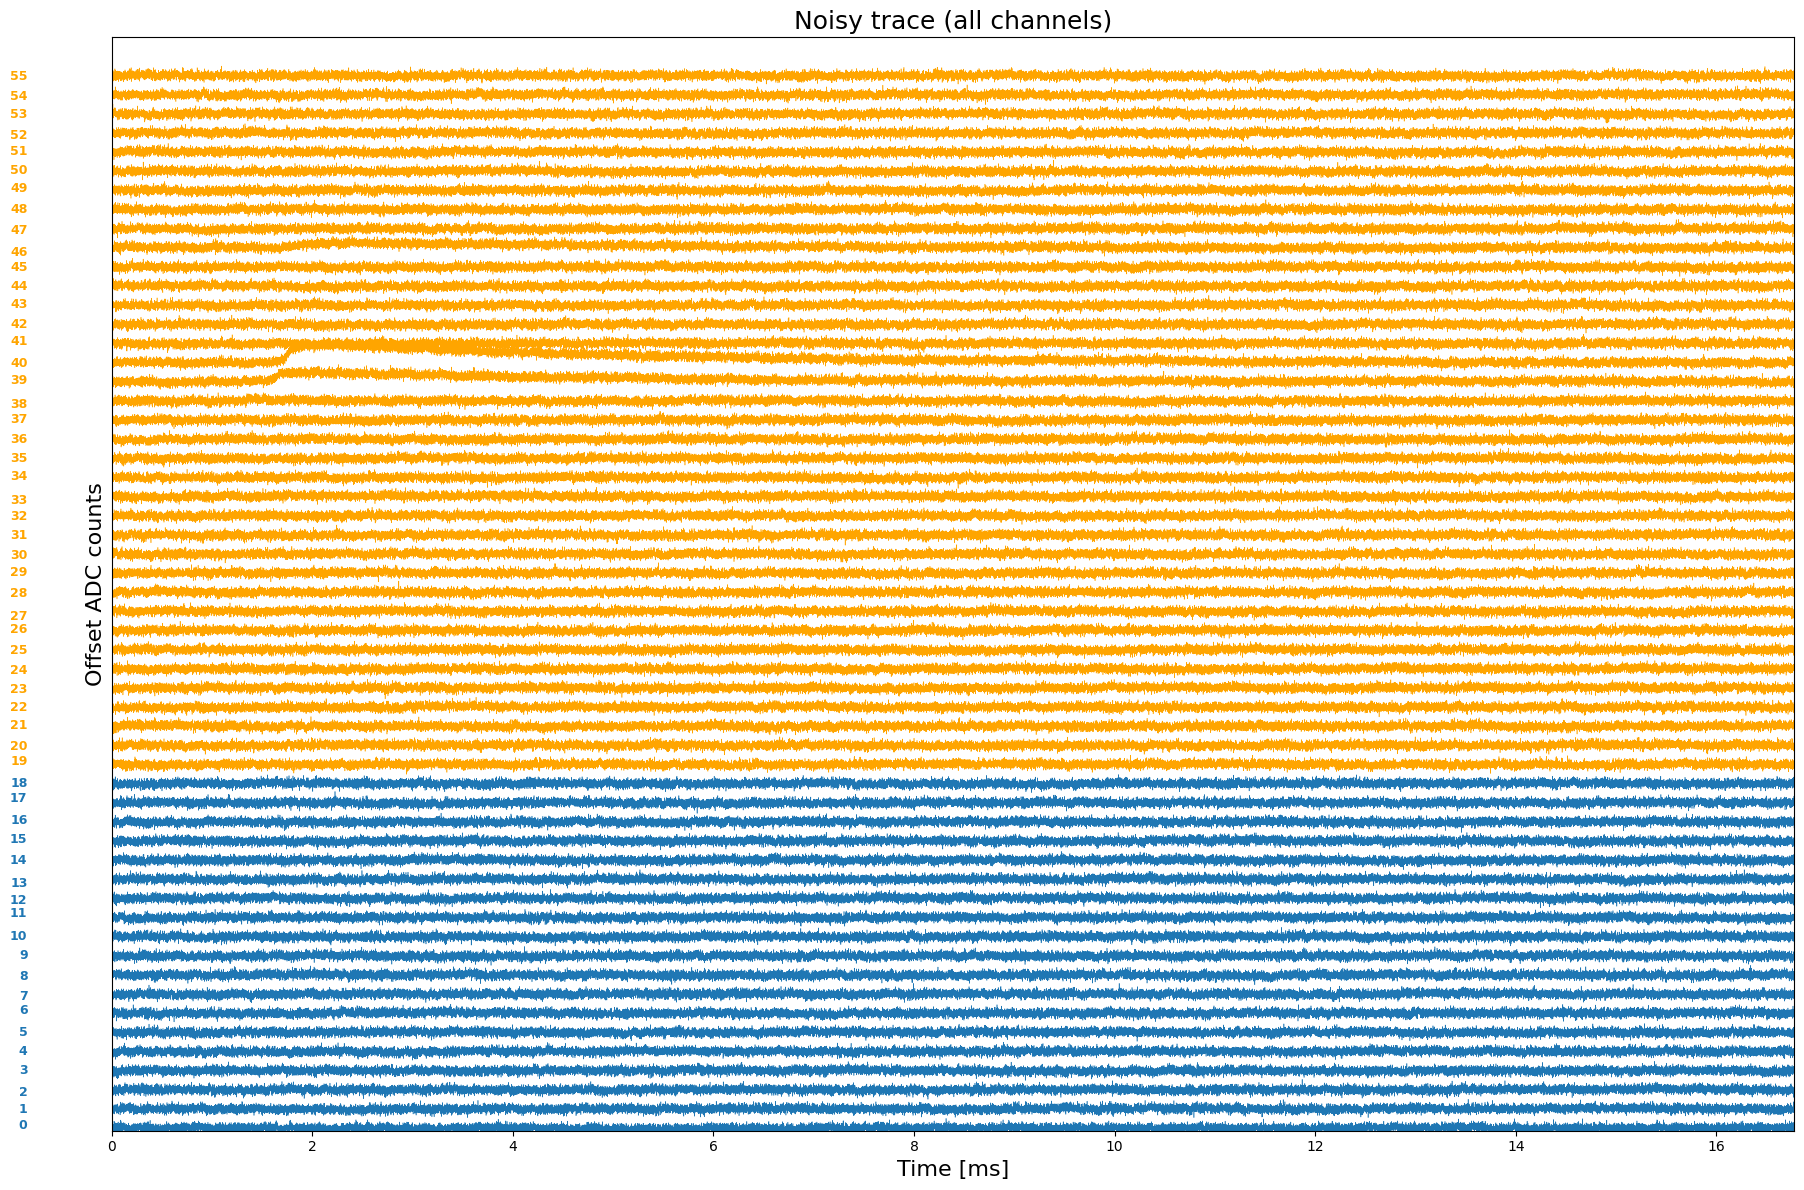

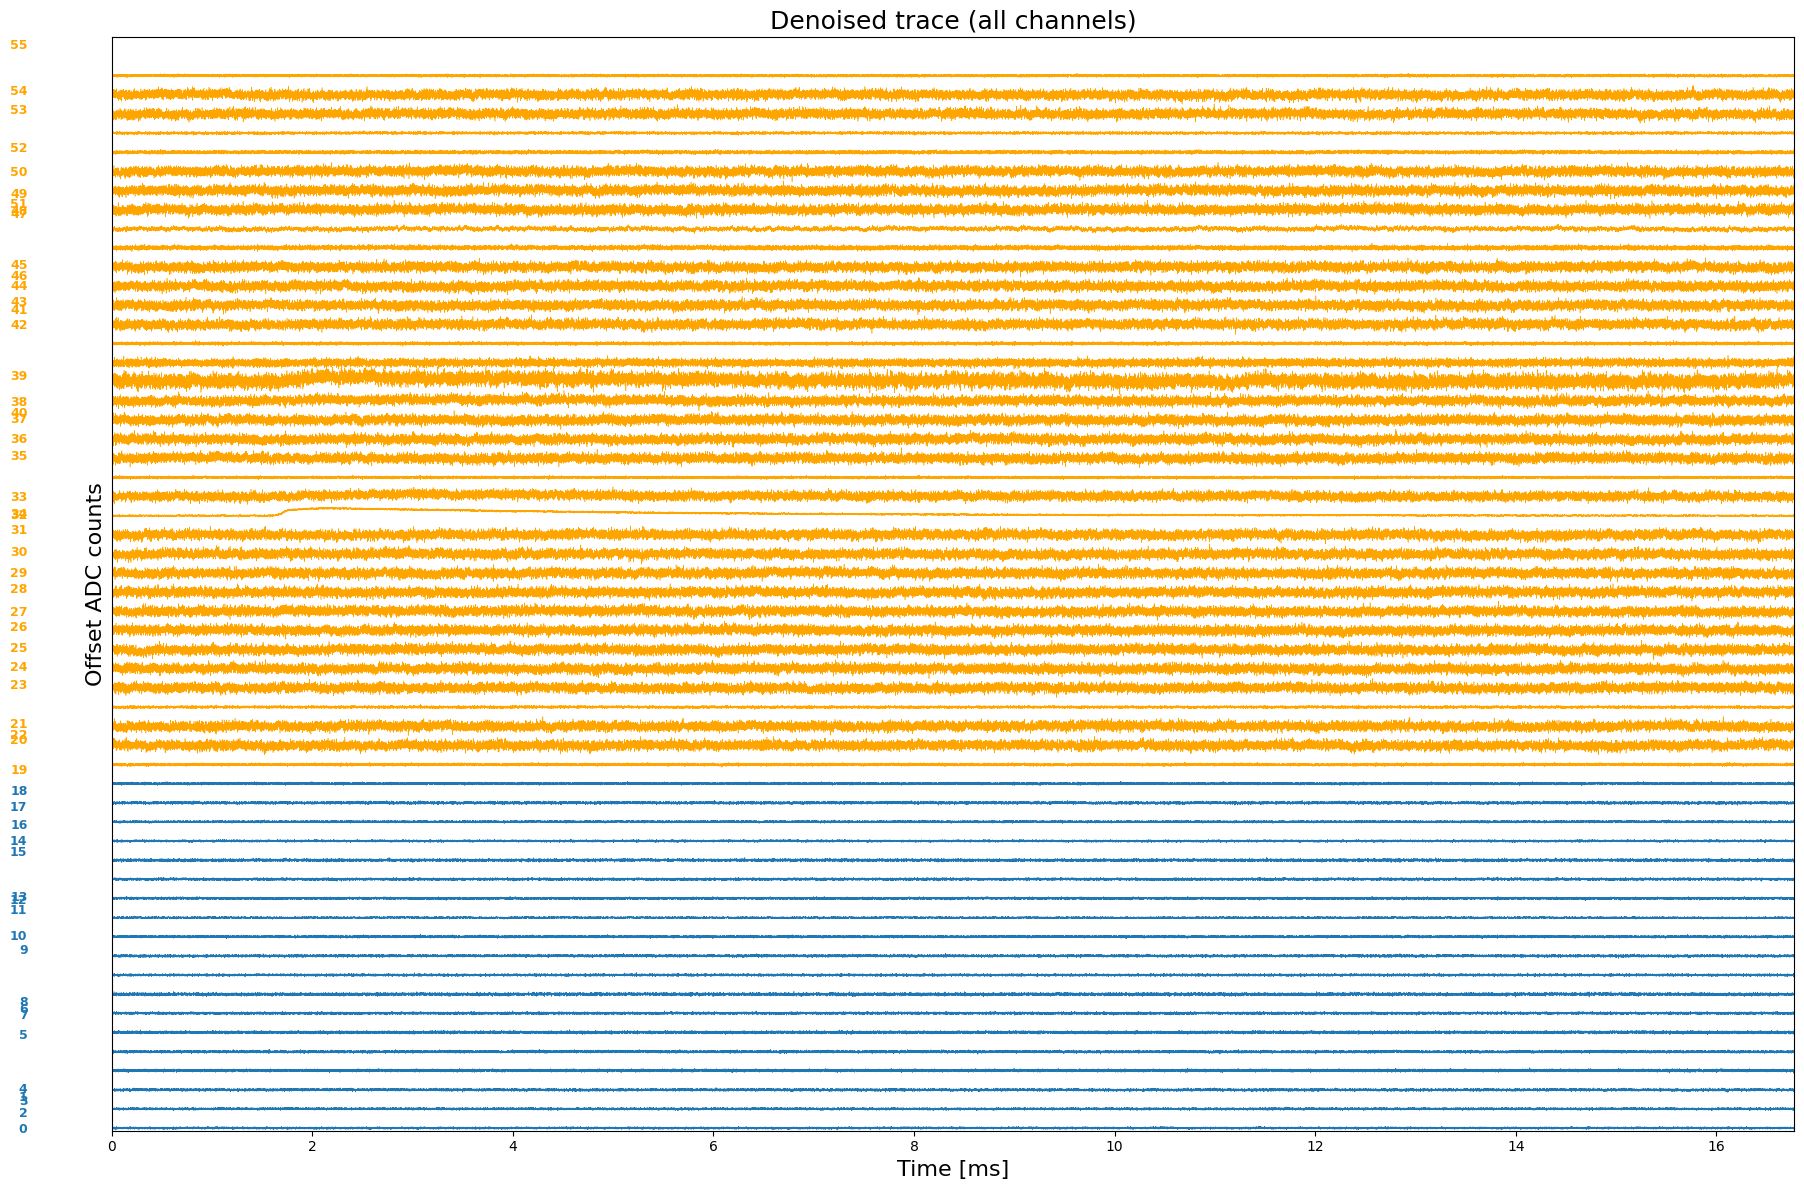

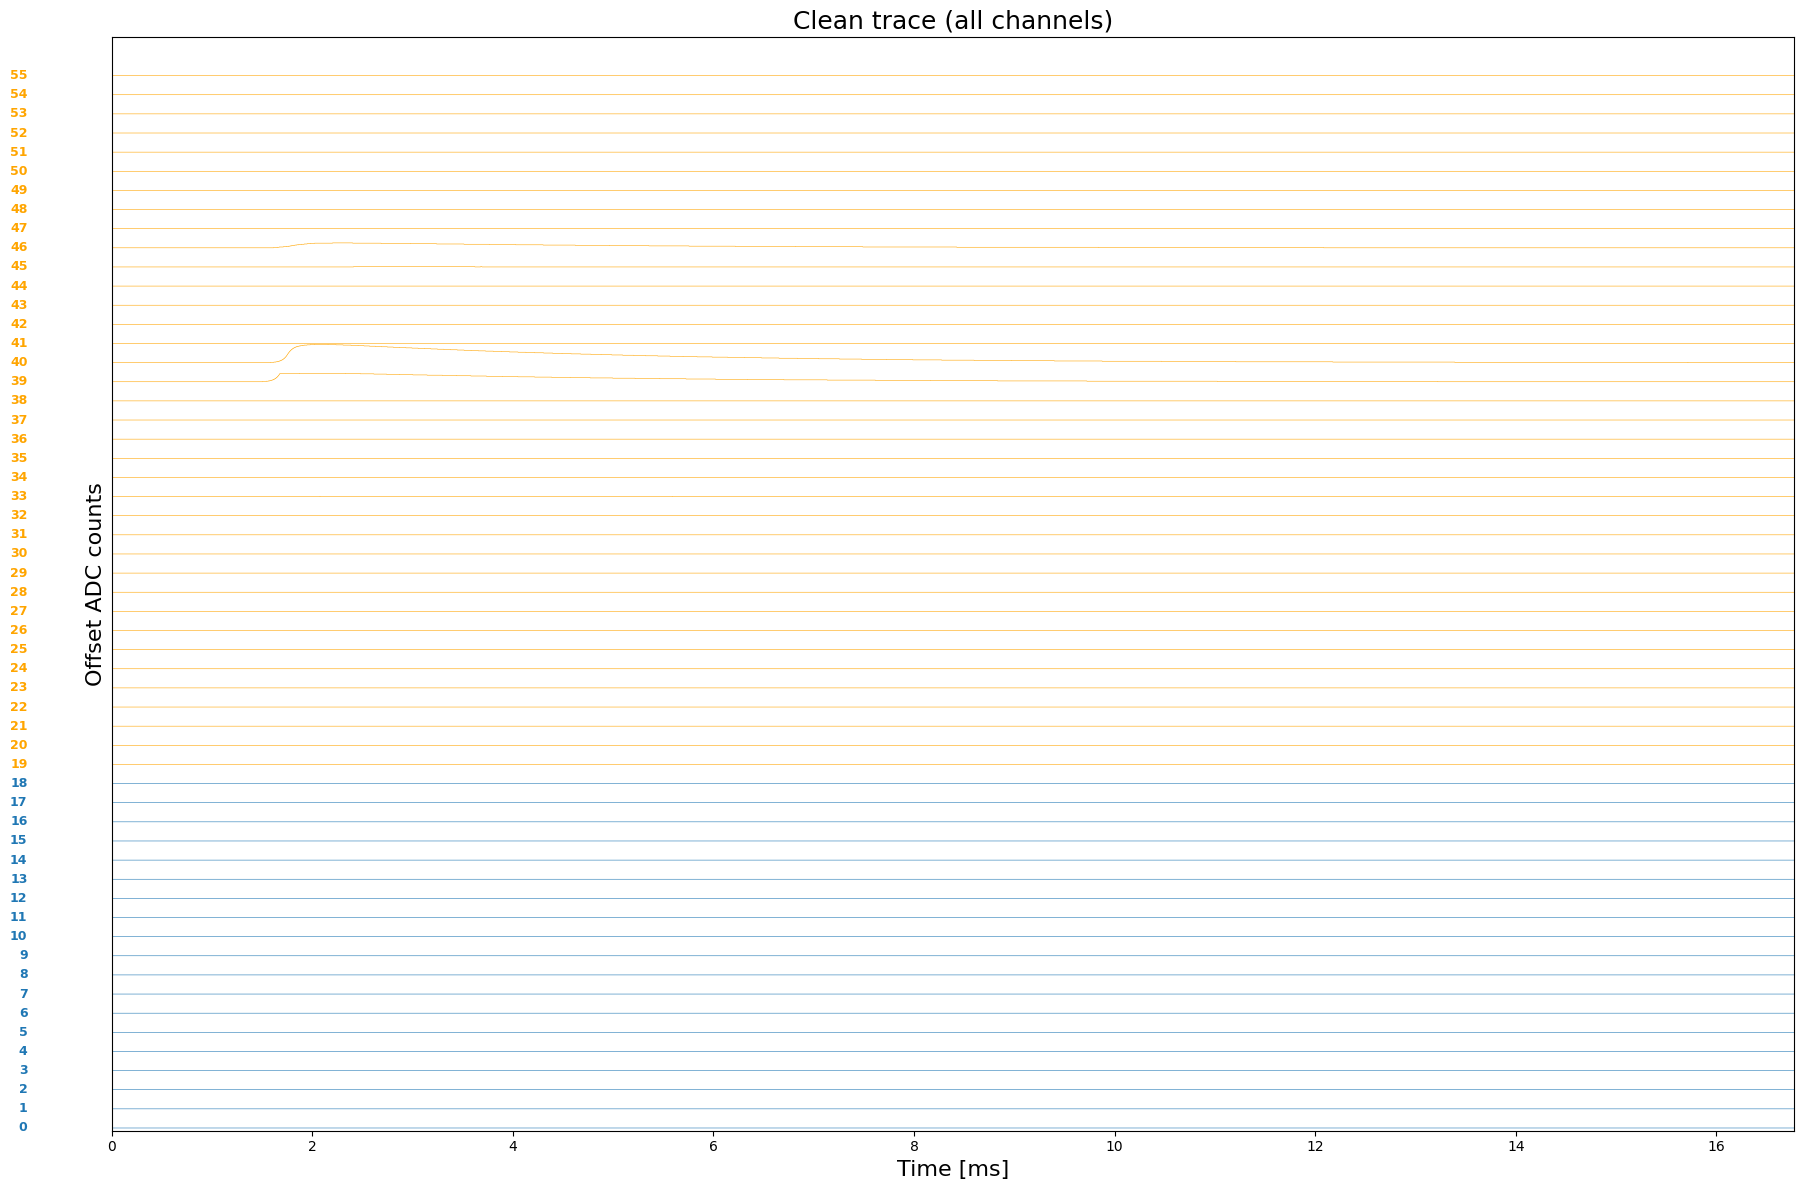

In [89]:
# Plot all channels for one event using trace_IO styling
idx_plot = min(plot_idx, pred_denorm.shape[0] - 1)
print(f"Plotting event {idx_plot}")
plot_traces(noisy_orig[idx_plot].numpy(), title="Noisy trace (all channels)")
plot_traces(pred_denorm[idx_plot].numpy(), title="Denoised trace (all channels)")
plot_traces(clean_orig[idx_plot].numpy(), title="Clean trace (all channels)")
